In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pint

from cfspopcon.algorithm_class import Algorithm
from cfspopcon.helpers import get_item
from cfspopcon.unit_handling import Unitfull, ureg
from cfspopcon.formulas.atomic_data import AtomicData
from cfspopcon.formulas.geometry.volume_integral import integrate_profile_over_volume
from cfspopcon.named_options import AtomicSpecies


In [2]:
#Profiles copied from external code
ne_prof_ips = np.array([2.762307e+01, 2.762307e+01, 2.757546e+01, 2.752447e+01, 2.747012e+01, 
2.741246e+01, 2.735155e+01, 2.728741e+01, 2.722011e+01, 2.714968e+01, 
2.707616e+01, 2.699961e+01, 2.692007e+01, 2.683757e+01, 2.675218e+01, 
2.666392e+01, 2.657285e+01, 2.647901e+01, 2.638245e+01, 2.628320e+01, 
2.618132e+01, 2.607685e+01, 2.596984e+01, 2.586032e+01, 2.574835e+01, 
2.563396e+01, 2.551721e+01, 2.539814e+01, 2.527679e+01, 2.515320e+01, 
2.502743e+01, 2.489951e+01, 2.476950e+01, 2.463743e+01, 2.450335e+01, 
2.436731e+01, 2.422934e+01, 2.408951e+01, 2.394784e+01, 2.380438e+01, 
2.365919e+01, 2.351230e+01, 2.336375e+01, 2.321360e+01, 2.306189e+01, 
2.290866e+01, 2.275396e+01, 2.259783e+01, 2.244031e+01, 2.228146e+01, 
2.212132e+01, 2.195992e+01, 2.179732e+01, 2.163356e+01, 2.146868e+01, 
2.130274e+01, 2.113577e+01, 2.096781e+01, 2.079892e+01, 2.062914e+01, 
2.045851e+01, 2.028708e+01, 2.011488e+01, 1.994197e+01, 1.976839e+01, 
1.959418e+01, 1.941937e+01, 1.924402e+01, 1.906815e+01, 1.889181e+01, 
1.871501e+01, 1.853780e+01, 1.836017e+01, 1.818213e+01, 1.800366e+01, 
1.782472e+01, 1.764521e+01, 1.746499e+01, 1.728385e+01, 1.710142e+01, 
1.691722e+01, 1.673048e+01, 1.654013e+01, 1.634462e+01, 1.614177e+01, 
1.592848e+01, 1.570050e+01, 1.545207e+01, 1.517559e+01, 1.486152e+01, 
1.449866e+01, 1.407535e+01, 1.358208e+01, 1.301563e+01, 1.238413e+01, 
1.171056e+01, 1.103139e+01, 1.038888e+01, 9.819731e+00, 9.346060e+00, 
8.972966e+00])*1e19

Te_prof_ips = [1.881676e+01, 1.881676e+01, 1.874542e+01, 1.866825e+01, 1.858537e+01, 
1.849692e+01, 1.840301e+01, 1.830379e+01, 1.819937e+01, 1.808987e+01, 
1.797544e+01, 1.785620e+01, 1.773226e+01, 1.760377e+01, 1.747084e+01, 
1.733360e+01, 1.719219e+01, 1.704672e+01, 1.689733e+01, 1.674414e+01, 
1.658728e+01, 1.642688e+01, 1.626305e+01, 1.609594e+01, 1.592567e+01, 
1.575236e+01, 1.557614e+01, 1.539714e+01, 1.521549e+01, 1.503131e+01, 
1.484473e+01, 1.465587e+01, 1.446487e+01, 1.427185e+01, 1.407694e+01, 
1.388026e+01, 1.368195e+01, 1.348213e+01, 1.328092e+01, 1.307845e+01, 
1.287486e+01, 1.267026e+01, 1.246479e+01, 1.225857e+01, 1.205173e+01, 
1.184439e+01, 1.163669e+01, 1.142874e+01, 1.122069e+01, 1.101265e+01, 
1.080475e+01, 1.059712e+01, 1.038988e+01, 1.018317e+01, 9.977101e+00, 
9.771813e+00, 9.567429e+00, 9.364075e+00, 9.161880e+00, 8.960969e+00, 
8.761470e+00, 8.563510e+00, 8.367216e+00, 8.172715e+00, 7.980134e+00, 
7.789599e+00, 7.601238e+00, 7.415176e+00, 7.231539e+00, 7.050454e+00, 
6.872044e+00, 6.696433e+00, 6.523741e+00, 6.354087e+00, 6.187582e+00, 
6.024333e+00, 5.864432e+00, 5.707953e+00, 5.554943e+00, 5.405404e+00, 
5.259271e+00, 5.116376e+00, 4.976390e+00, 4.838742e+00, 4.702489e+00, 
4.566127e+00, 4.427311e+00, 4.282468e+00, 4.126293e+00, 3.951178e+00, 
3.746797e+00, 3.500332e+00, 3.198285e+00, 2.830948e+00, 2.399574e+00, 
1.923139e+00, 1.438300e+00, 9.885116e-01, 6.078189e-01, 3.107985e-01, 
9.381087e-02] 

#Defining variables as DataArrays
rho = xr.DataArray(
    data = np.linspace(0,1,len(Te_prof_ips)),
    name = 'rho')

Te_prof = xr.DataArray(
    data = Te_prof_ips,
    name = 'electron_temp_profile',
    coords={"dim_average_electron_temp":7.7,
            "dim_average_electron_density":18.6},
    dims="dim_rho"
)
ne_prof = xr.DataArray(
    data = ne_prof_ips,
    name = 'electron_density_profile',
    coords={"dim_average_electron_temp":7.7,
            "dim_average_electron_density":18.6},
    dims="dim_rho"
)
imp_conc = xr.DataArray(
    data = 0.002,
    name = 'impurity_concentration',
    coords={"dim_average_electron_temp":7.7,
            "dim_average_electron_density":18.6,
            "dim_species":AtomicSpecies.Argon}
)

#Assigning variables appropriate units
ne_prof= ne_prof.pint.quantify({"electron_density_profile":"meter ** -3"})
Te_prof= Te_prof.pint.quantify({"electron_temp_profile":"kiloelectron_volt"})
imp_conc = imp_conc.pint.quantify({"impurity_concentration":"dimensionless"})

#Assigning AtomicData
ad = AtomicData(Path() / "radas_dir")

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [ ]:
interpolator = ad.get_coronal_Lz_interpolator(get_item(imp_conc.dim_species))
Lz = interpolator.vector_eval(electron_density=ne_prof, electron_temp=Te_prof, allow_extrap=True)


In [10]:
qrad = np.array([-2.993040e-01, -2.993040e-01, -2.975609e-01, -2.956926e-01, -2.937029e-01,
-2.915952e-01, -2.893732e-01, -2.870406e-01, -2.846012e-01, -2.820586e-01,
-2.794169e-01, -2.766797e-01, -2.738510e-01, -2.709347e-01, -2.679347e-01,
-2.648549e-01, -2.616994e-01, -2.584720e-01, -2.551767e-01, -2.518174e-01,
-2.483983e-01, -2.449230e-01, -2.413957e-01, -2.378202e-01, -2.342004e-01,
-2.305402e-01, -2.268435e-01, -2.231139e-01, -2.193554e-01, -2.155717e-01,
-2.117664e-01, -2.079433e-01, -2.041059e-01, -2.002578e-01, -1.964024e-01,
-1.925433e-01, -1.886838e-01, -1.848272e-01, -1.809768e-01, -1.771357e-01,
-1.733070e-01, -1.694938e-01, -1.656990e-01, -1.619254e-01, -1.581757e-01,
-1.544527e-01, -1.507590e-01, -1.470969e-01, -1.434688e-01, -1.398771e-01,
-1.363238e-01, -1.328111e-01, -1.293408e-01, -1.259147e-01, -1.225347e-01,
-1.192022e-01, -1.159187e-01, -1.126857e-01, -1.095043e-01, -1.063757e-01,
-1.033010e-01, -1.002809e-01, -9.731647e-02, -9.440824e-02, -9.155687e-02,
-8.876287e-02, -8.602665e-02, -8.334854e-02, -8.072876e-02, -7.816745e-02,
-7.566464e-02, -7.322026e-02, -7.083414e-02, -6.850592e-02, -6.623509e-02,
-6.402091e-02, -6.186230e-02, -5.975776e-02, -5.770521e-02, -5.570169e-02,
-5.374312e-02, -5.182372e-02, -4.993541e-02, -4.806685e-02, -4.620224e-02,
-4.431968e-02, -4.238924e-02, -4.037092e-02, -3.821309e-02, -3.585289e-02,
-3.322104e-02, -3.025481e-02, -2.692223e-02, -2.325568e-02, -1.938062e-02,
-1.551295e-02, -1.190432e-02, -8.752743e-03, -6.131996e-03, -3.972027e-03,
-2.011473e-03])

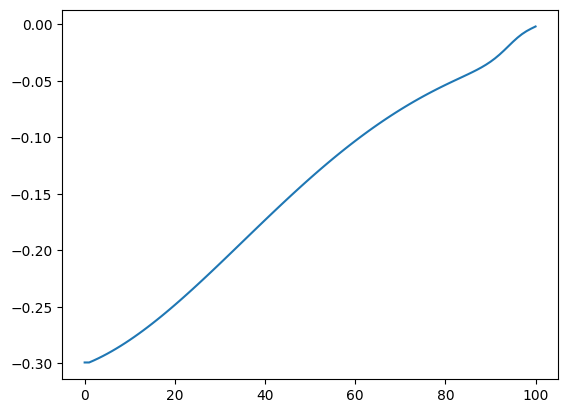

In [11]:
plt.plot(qrad)

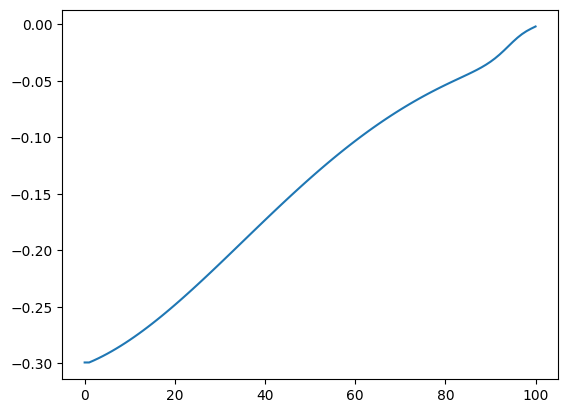

In [12]:
qrad = [-2.993040e-01, -2.993040e-01, -2.975609e-01, -2.956926e-01, -2.937029e-01,
-2.915952e-01, -2.893732e-01, -2.870406e-01, -2.846012e-01, -2.820586e-01,
-2.794169e-01, -2.766797e-01, -2.738510e-01, -2.709347e-01, -2.679347e-01,
-2.648549e-01, -2.616994e-01, -2.584720e-01, -2.551767e-01, -2.518174e-01,
-2.483983e-01, -2.449230e-01, -2.413957e-01, -2.378202e-01, -2.342004e-01,
-2.305402e-01, -2.268435e-01, -2.231139e-01, -2.193554e-01, -2.155717e-01,
-2.117664e-01, -2.079433e-01, -2.041059e-01, -2.002578e-01, -1.964024e-01,
-1.925433e-01, -1.886838e-01, -1.848272e-01, -1.809768e-01, -1.771357e-01,
-1.733070e-01, -1.694938e-01, -1.656990e-01, -1.619254e-01, -1.581757e-01,
-1.544527e-01, -1.507590e-01, -1.470969e-01, -1.434688e-01, -1.398771e-01,
-1.363238e-01, -1.328111e-01, -1.293408e-01, -1.259147e-01, -1.225347e-01,
-1.192022e-01, -1.159187e-01, -1.126857e-01, -1.095043e-01, -1.063757e-01,
-1.033010e-01, -1.002809e-01, -9.731647e-02, -9.440824e-02, -9.155687e-02,
-8.876287e-02, -8.602665e-02, -8.334854e-02, -8.072876e-02, -7.816745e-02,
-7.566464e-02, -7.322026e-02, -7.083414e-02, -6.850592e-02, -6.623509e-02,
-6.402091e-02, -6.186230e-02, -5.975776e-02, -5.770521e-02, -5.570169e-02,
-5.374312e-02, -5.182372e-02, -4.993541e-02, -4.806685e-02, -4.620224e-02,
-4.431968e-02, -4.238924e-02, -4.037092e-02, -3.821309e-02, -3.585289e-02,
-3.322104e-02, -3.025481e-02, -2.692223e-02, -2.325568e-02, -1.938062e-02,
-1.551295e-02, -1.190432e-02, -8.752743e-03, -6.131996e-03, -3.972027e-03,
-2.011473e-03]
plt.plot(qrad)